In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class BVP:
    def __init__(self, patient, quadrant, signal, features, id):
        self.patient = patient
        self.quadrant = quadrant
        self.signal = signal
        self.features = features
        self.id = id

In [3]:
patients = list(range(1, 62))
patients.remove(23)

quadrants = [
    "Q1_1",
    "Q1_2",
    "Q2_1",
    "Q2_2",
    "Q3_1",
    "Q3_2",
    "Q4_1",
    "Q4_2",
    "Q5_1",
    "Q5_2",
    "Q6_1",
    "Q6_2",
    "Q7_1",
    "Q7_2",
    "Q8_1",
    "Q8_2",
    "Q9_1",
    "Q9_2"
]

In [4]:
base_path_video = "../BVPs"

failed_masks = [
    [2, "Q1_1"],
    [52, "Q7_2"],
    [53, "Q4_2"]
]

In [5]:
BVPs = []

for patient in patients:

    for quadrant in quadrants:

        if [patient, quadrant] in failed_masks:
            print(f"Skipping Patient_{patient}, {quadrant}")
            continue

        data = np.load(f"{base_path_video}/Patient_{patient}/{quadrant}.npy")

        #for t_start, t_end in getattr(timestamps, quadrant):

        #data_cut = cut_bvp(data, t_start, t_end, fs)

        id = f"{patient}{quadrant}"

        bvp = BVP(patient, quadrant, data, [], id)

        BVPs.append(bvp)

        #print(f"Patient_{patient}, {quadrant}: {data.shape}")

print(f"Loaded {len(BVPs)} BVP signals")

Skipping Patient_2, Q1_1
Skipping Patient_52, Q7_2
Skipping Patient_53, Q4_2
Loaded 1077 BVP signals


Text(0.5, 1.0, 'Patient_14, Q1_2')

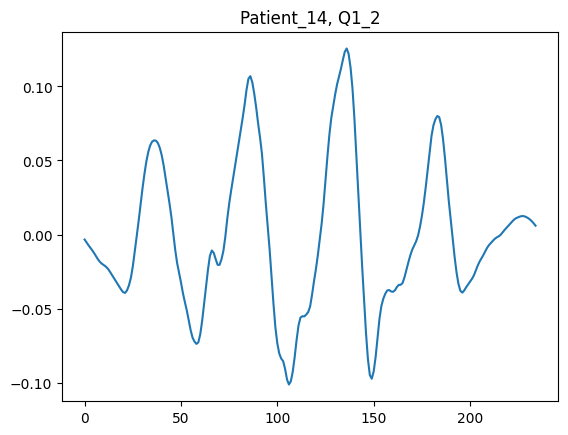

In [13]:
patient = 14
quadrant = [1, 1]

idx = (patient - 1)*18 + (quadrant[0] - 1)*2 + (quadrant[1] - 1)

# if patient >= 2:
#     idx = idx - 1
#     if patient >= 52:
#         if quadrant[0] >= 7:

bvp = BVPs[idx]

plt.plot(bvp.signal)
plt.title(f"Patient_{bvp.patient}, {bvp.quadrant}")